En este archivo me propongo a re-procesar los datos y ver que filtros funcionan mejor

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter #este es el filtro de savitzky-golay 
from scipy.ndimage import gaussian_filter1d #Otro tipo de filtro q por ahi uso
from scipy.interpolate import UnivariateSpline #Esto fitea una "spline". Es como un polinomio pero mas piola, es otro filtro nomas 


In [ ]:
df = pd.read_csv('mediciones/20260528_103840_balanza_multimetro/20260528_103840_datos_sincronizados_nearest.csv')

In [20]:
df

,tiempo_s,tiempo_multimetro_s,voltaje_V,indice_multimetro,fecha_hora_corregida_hp,fecha_hora_pc_sin_corregir_hp,error_hp,tiempo_balanza_s,masa_g,indice_balanza,fecha_hora_corregida_balanza,fecha_hora_pc_sin_corregir_balanza,error_balanza,delta_t_balanza_multimetro_s
0,0.415754,0.415754,0.001141,0,2026-05-28T10:38:45.228,2026-05-28T10:54:15.228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.632200,0.632200,0.001138,1,2026-05-28T10:38:45.438,2026-05-28T10:54:15.438,NaN,1.434101,NaN,0.0,2026-05-28T10:38:46.245,2026-05-28T10:54:16.245,Error desde Arduino: HX711 not found.,0.801902
2,0.847464,0.847464,0.001137,2,2026-05-28T10:38:45.655,2026-05-28T10:54:15.655,NaN,1.434101,NaN,0.0,2026-05-28T10:38:46.245,2026-05-28T10:54:16.245,Error desde Arduino: HX711 not found.,0.586637
3,1.062519,1.062519,0.001133,3,2026-05-28T10:38:45.872,2026-05-28T10:54:15.872,NaN,1.434101,NaN,0.0,2026-05-28T10:38:46.245,2026-05-28T10:54:16.245,Error desde Arduino: HX711 not found.,0.371583
4,1.277455,1.277455,0.001134,4,2026-05-28T10:38:46.088,2026-05-28T10:54:16.088,NaN,1.434101,NaN,0.0,2026-05-28T10:38:46.245,2026-05-28T10:54:16.245,Error desde Arduino: HX711 not found.,0.156647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,179.213393,179.213393,-0.005876,831,2026-05-28T10:41:44.022,2026-05-28T10:57:14.022,NaN,179.013764,-53.56,358.0,2026-05-28T10:41:43.825,2026-05-28T10:57:13.825,NaN,-0.199629
832,179.428470,179.428470,-0.005876,832,2026-05-28T10:41:44.238,2026-05-28T10:57:14.238,NaN,179.513605,-53.56,359.0,2026-05-28T10:41:44.322,2026-05-28T10:57:14.322,NaN,0.085135
833,179.643612,179.643612,-0.005876,833,2026-05-28T10:41:44.448,2026-05-28T10:57:14.448,NaN,179.513605,-53.56,359.0,2026-05-28T10:41:44.322,2026-05-28T10:57:14.322,NaN,-0.130008
834,179.858832,179.858832,-0.005876,834,2026-05-28T10:41:44.670,2026-05-28T10:57:14.670,NaN,179.513605,-53.56,359.0,2026-05-28T10:41:44.322,2026-05-28T10:57:14.322,NaN,-0.345227


In [21]:
t = df['tiempo_s']
V = df['voltaje_V']

T_ref_C = 0

def convert_type_k_volts_to_c(V_array, T_ref=T_ref_C):
    """
    Convierte un array de voltajes en V a C dado una termocupla tipo K. Necesita la temp de referencia en C.
    """
    V_mV = np.array(V_array) * 1000.0
    
    # 2. Cold Junction Compensation (CJC)
    # We must add the voltage the thermocouple *would* be producing at the reference temp.
    # Near 0-4 °C, a Type K produces a nearly perfectly linear ~0.03948 mV per °C.
    V_ref_mV = T_ref * 0.03948 
    
    # True absolute thermoelectric voltage
    V_true_mV = V_mV + V_ref_mV
    
    # 3. NIST Polynomial Coefficients for Voltage -> Temperature (°C)
    # c_neg: For the negative voltage range (-200°C to 0°C)
    c_neg = [0, 25.173462, -1.1662878, -1.0833638, -0.89773540, 
             -0.37342377, -0.086632643, -0.010450598, -0.00051920577]
             
    # c_pos: For the positive voltage range (0°C to 500°C)
    c_pos = [0, 25.08355, 0.07860106, -0.2503131, 0.08315270, 
             -0.01228034, 0.0009804036, -4.413030E-05, 1.057734E-06, -1.052755E-08]
    
    # np.polyval evaluates polynomials, but expects coefficients from highest degree to lowest.
    # Our NIST lists are from degree 0 to N, so we reverse them using [::-1]
    T_neg = np.polyval(c_neg[::-1], V_true_mV)
    T_pos = np.polyval(c_pos[::-1], V_true_mV)
    
    # 4. Choose the correct polynomial based on whether the measured voltage is < 0 mV
    T_celsius = np.where(V_true_mV < 0, T_neg, T_pos)
    
    return T_celsius

T = convert_type_k_volts_to_c(V)

W = df['masa_g']

In [22]:
data = pd.DataFrame({'Tiempo (s)': t, 'Temperatura (°C)': T, 'Masa (g)': W}).to_csv('data_test.csv')

Text(0, 0.5, 'Masa (g)')

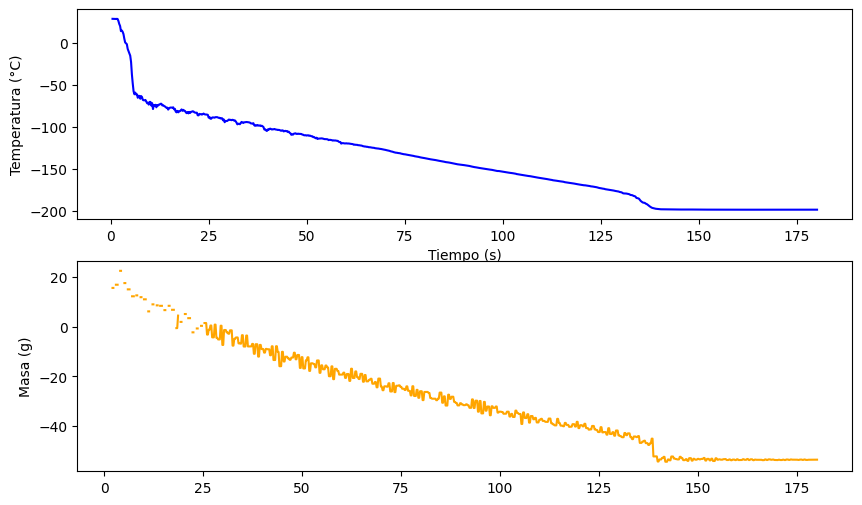

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(10,6))
ax[0].plot(t, T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(t, W, label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


In [7]:
df = pd.read_csv('data_test.csv')

In [8]:
df['Temperatura (°C)']

0       25.762525
1       25.747750
2       25.752155
3       25.750348
4       25.724956
          ...    
831   -199.407694
832   -199.404994
833   -199.408401
834   -199.407694
835   -199.403644
Name: Temperatura (°C), Length: 836, dtype: float64

In [9]:
t= df['Tiempo (s)']
T = df['Temperatura (°C)']
W = df['Masa (g)']

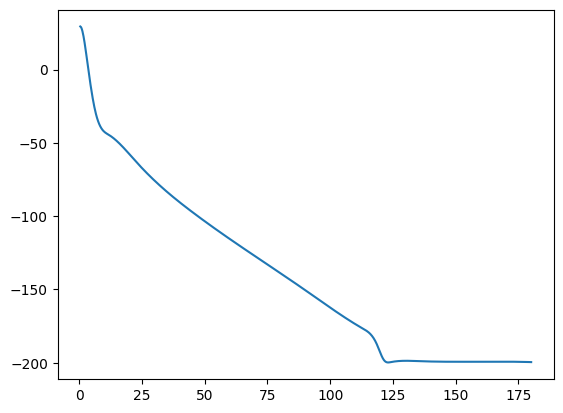

In [15]:
spline = UnivariateSpline(t, T, s=1000)
T_smooth_spline = spline(t)
plt.plot(t,T_smooth_spline)

funciona bastante bien fitear una spline eh

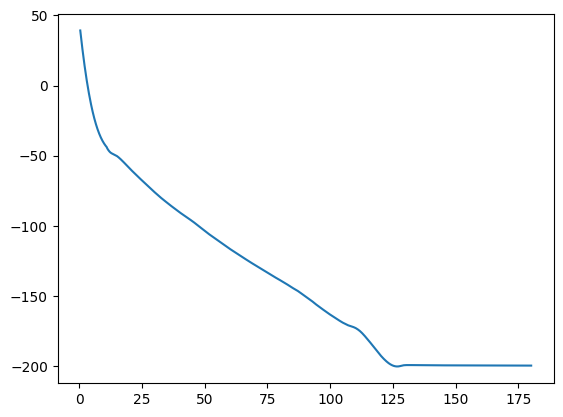

In [16]:
T_smooth_savgol = savgol_filter(T, window_length=100, polyorder=3)
plt.plot(t,T_smooth_savgol)

Doma savgol. Pero aun hay un problemita con la zona de 0 a 5s.

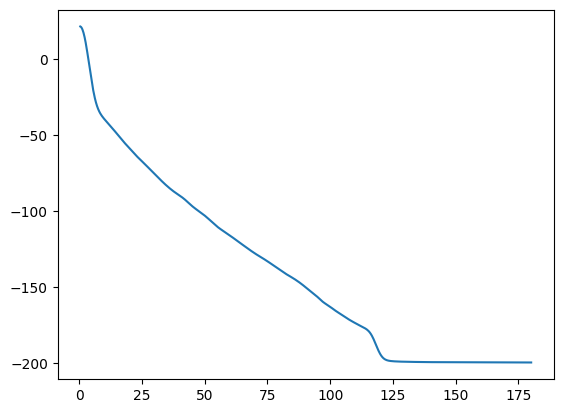

In [12]:
T_smooth_gaussian = gaussian_filter1d(T, sigma=8)
plt.plot(t,T_smooth_gaussian)

El filtro gaussiano es con diferencia absurda el mejor xd 

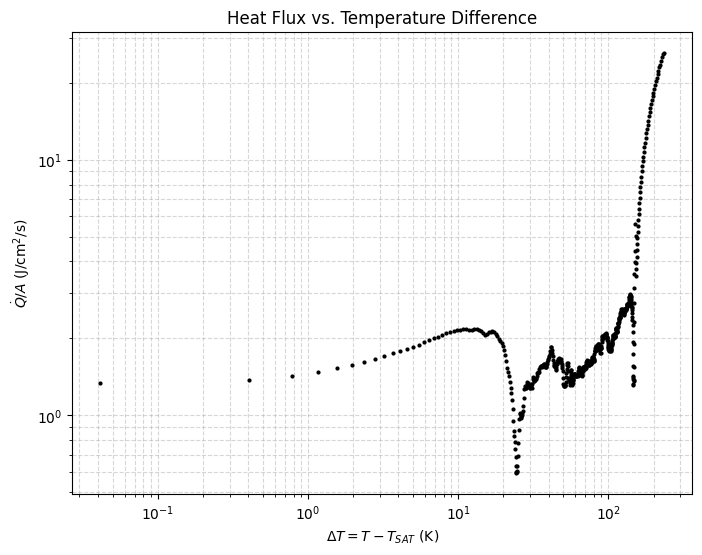

In [17]:
# --- 1. Your Experimental Constants ---
# UPDATE THESE FOR YOUR SPECIFIC SAMPLE
mass_g = 164.88             # Update based on your sample's mass
molar_mass_g_mol = 63.546 # 63.546 for Copper, 26.98 for Aluminum, etc.
area_cm2 = 37.7           # Update with your sample's surface area

n_moles = mass_g / molar_mass_g_mol
T_sat_K = 77.36           # Saturation temperature of liquid N2

# --- 2. Convert Data to Kelvin ---
T_K = T_smooth_savgol+ 273.15

# --- 3. Calculate the Derivative (dT/dt) ---
# np.gradient works perfectly for your smoothed data
dT_dt = np.gradient(T_K, t)
cooling_rate = -dT_dt # We want a positive cooling rate for the flux

# --- 4. Temperature-Dependent Heat Capacity ---
# The paper uses the Einstein model approximation: theta_E = 0.77 * theta_D
R = 8.314        # Universal gas constant in J/(mol*K)
theta_D = 315.0  # Debye temperature for Copper in K (Update if not using Copper)
theta_E = 0.77 * theta_D

# Calculate Cv(T) for every temperature point in your array
term1 = 3 * R * (theta_E / T_K)**2
term2 = np.exp(theta_E / T_K) / (np.exp(theta_E / T_K) - 1)**2
Cv_T = term1 * term2

# --- 5. Calculate Heat Flux (Q_dot / A) ---
# Formula from paper: Q_dot / A = (n / A) * C(T) * (dT/dt)
Q_dot_A = (n_moles / area_cm2) * Cv_T * cooling_rate

# --- 6. Recreate Figure 5 (Log-Log Plot) ---
delta_T = T_K - T_sat_K

# Filter out physical impossibilities (like floating point errors at the tail end)
valid = (delta_T > 0) & (Q_dot_A > 0)

plt.figure(figsize=(8, 6))
plt.loglog(delta_T[valid], Q_dot_A[valid], 'k.', markersize=4)

plt.xlabel(r'$\Delta T = T - T_{SAT}$ (K)')
plt.ylabel(r'$\dot{Q}/A$ (J/cm$^2$/s)')
plt.title('Heat Flux vs. Temperature Difference')
plt.grid(True, which="both", ls="--", alpha=0.5)
# plt.ylim(0.1,10)
# plt.xlim(0,100)

plt.show()

Y que pasa si fiteo con una sigmoide?

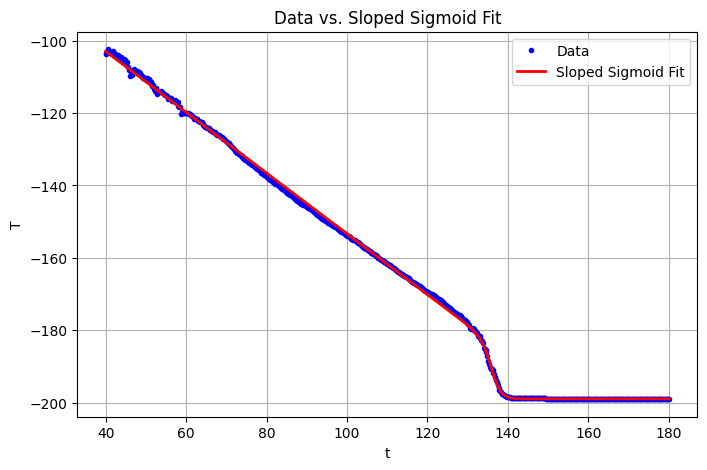

Fitted Left Slope (m): -0.839
Fitted Left Intercept (c): -69.379
Fitted Right Plateau (L): -198.937
Fitted Steepness (k): 0.828
Fitted Inflection Time (t0): 136.163


In [48]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import expit

# 1. Define the sloped sigmoid
def sloped_sigmoid(t, m, c, L, k, t0):
    # expit is the standard logistic function 1/(1+exp(-x))
    w = expit(k * (t - t0))
    
    # Blends from the line (m*t + c) to the flat asymptote (L)
    linear_part = m * t + c
    return linear_part * (1 - w) + L * w

# 2. Chop data (assuming t and T are your arrays)
chop_time = 40
mask = t > chop_time
t_clean = t[mask]
T_clean = T[mask]

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Assuming your chopped arrays are t_clean and T_clean

def sloped_sigmoid(t, m, c, L, k, t0):
    # np.clip prevents overflow in the exponential during fitting
    exponent = np.clip(k * (t - t0), -500, 500)
    return L + (m * t + c - L) / (1 + np.exp(exponent))

# 1. Intelligent initial guesses (Crucial for this function)
# Based on your image's axes:
L_guess = -200          # The flat bottom plateau
t0_guess = 135          # Approximate x-value of the sharp drop
k_guess = 2.0           # Sharp transition (positive value)
m_guess = -0.8          # Approximate slope of the left linear region
c_guess = -110 - (m_guess * 50) # Approximate y-intercept of the left region

p0 = [m_guess, c_guess, L_guess, k_guess, t0_guess]

# 2. Fit the curve
popt, pcov = curve_fit(sloped_sigmoid, t_clean, T_clean, p0=p0)
m_fit, c_fit, L_fit, k_fit, t0_fit = popt

# 3. Plotting the results
plt.figure(figsize=(8, 5))

# Plot original chopped data
plt.plot(t_clean, T_clean, 'bo', label='Data', markersize=3)

# Generate smooth curve for the fit
t_fit_line = np.linspace(min(t_clean), max(t_clean), 100000)
T_fit_line = sloped_sigmoid(t_fit_line, *popt)

# Plot the fit
plt.plot(t_fit_line, T_fit_line, 'r-', label='Sloped Sigmoid Fit', linewidth=2)

plt.xlabel('t')
plt.ylabel('T')
plt.title('Data vs. Sloped Sigmoid Fit')
plt.legend()
plt.grid(True)
plt.show()

# Print the parameters
print(f"Fitted Left Slope (m): {m_fit:.3f}")
print(f"Fitted Left Intercept (c): {c_fit:.3f}")
print(f"Fitted Right Plateau (L): {L_fit:.3f}")
print(f"Fitted Steepness (k): {k_fit:.3f}")
print(f"Fitted Inflection Time (t0): {t0_fit:.3f}")

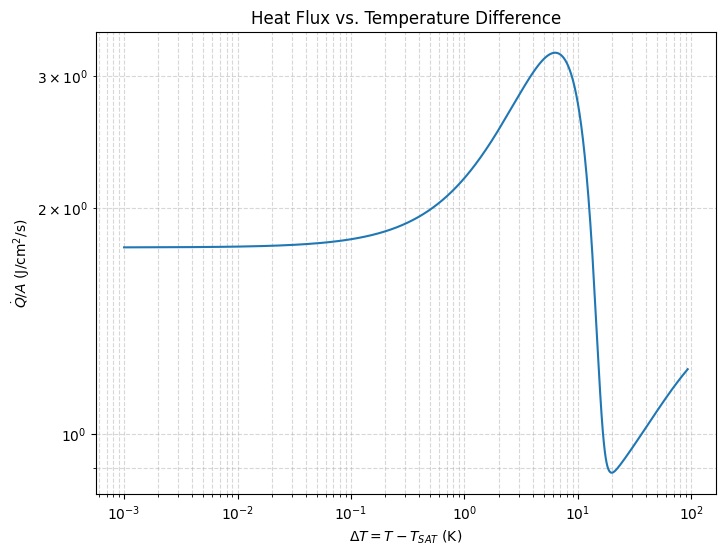

In [50]:
# --- 1. Your Experimental Constants ---
# UPDATE THESE FOR YOUR SPECIFIC SAMPLE
mass_g = 164.88             # Update based on your sample's mass
molar_mass_g_mol = 63.546 # 63.546 for Copper, 26.98 for Aluminum, etc.
area_cm2 = 37.7           # Update with your sample's surface area

n_moles = mass_g / molar_mass_g_mol
T_sat_K = 77.36           # Saturation temperature of liquid N2

# --- 2. Convert Data to Kelvin ---
T_K = T_fit_line+ 273.15

# --- 3. Calculate the Derivative (dT/dt) ---
# np.gradient works perfectly for your smoothed data
dT_dt = np.gradient(T_K, t_fit_line)
cooling_rate = -dT_dt # We want a positive cooling rate for the flux

# --- 4. Temperature-Dependent Heat Capacity ---
# The paper uses the Einstein model approximation: theta_E = 0.77 * theta_D
R = 8.314        # Universal gas constant in J/(mol*K)
theta_D = 315.0  # Debye temperature for Copper in K (Update if not using Copper)
theta_E = 0.77 * theta_D

# Calculate Cv(T) for every temperature point in your array
term1 = 3 * R * (theta_E / T_K)**2
term2 = np.exp(theta_E / T_K) / (np.exp(theta_E / T_K) - 1)**2
Cv_T = term1 * term2

# --- 5. Calculate Heat Flux (Q_dot / A) ---
# Formula from paper: Q_dot / A = (n / A) * C(T) * (dT/dt)
Q_dot_A = (n_moles / area_cm2) * Cv_T * cooling_rate

# --- 6. Recreate Figure 5 (Log-Log Plot) ---
delta_T = T_K - T_sat_K

# Filter out physical impossibilities (like floating point errors at the tail end)
valid = (delta_T > 0) & (Q_dot_A > 0)

plt.figure(figsize=(8, 6))
plt.loglog(delta_T[valid], Q_dot_A[valid], markersize=4)

plt.xlabel(r'$\Delta T = T - T_{SAT}$ (K)')
plt.ylabel(r'$\dot{Q}/A$ (J/cm$^2$/s)')
plt.title('Heat Flux vs. Temperature Difference')
plt.grid(True, which="both", ls="--", alpha=0.5)
# plt.ylim(0.1,10)
# plt.xlim(0,100)

plt.show()

Bueno si hay algo que queda claro de esta data es que lo unico que realmente funciona es fitear con una sigmoide.


Esto de aca abajo unicamente arma datos limpios 

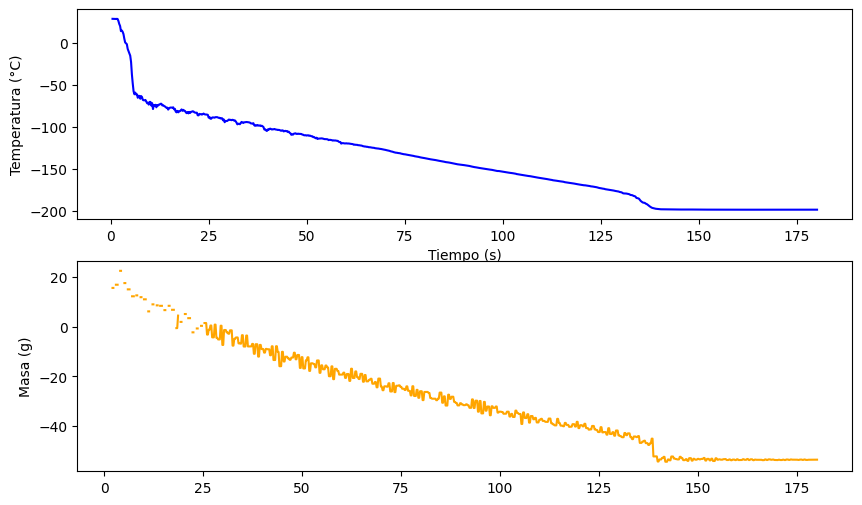

In [64]:
#C0 

df = pd.read_csv('mediciones/20260528_103840_balanza_multimetro/20260528_103840_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'])
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/C0.csv', index=False)

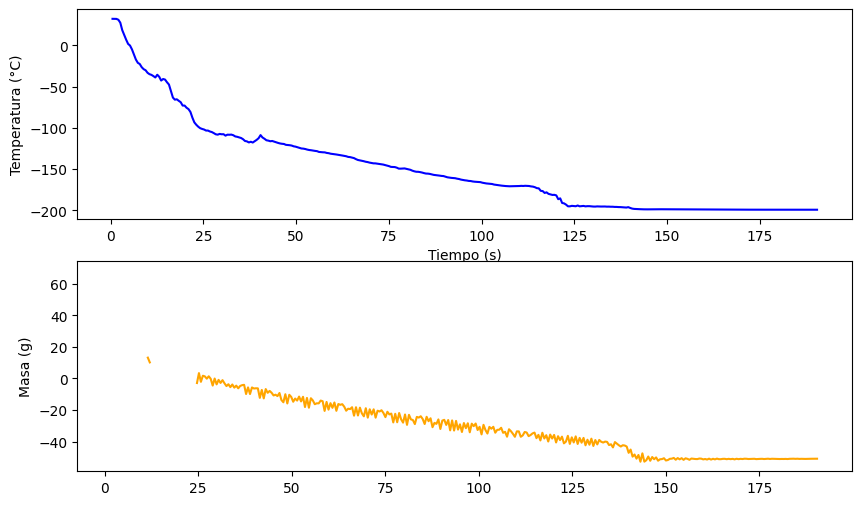

In [65]:
#C0_2

df = pd.read_csv('mediciones/20260528_102016_balanza_multimetro/20260528_102016_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'])
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/C0_2.csv', index=False)

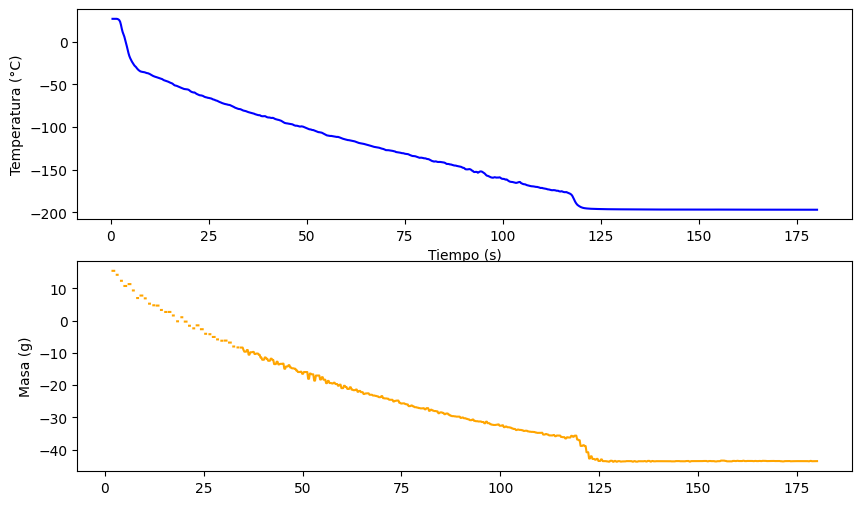

In [72]:
#A0


df = pd.read_csv('mediciones/20260528_110528_balanza_multimetro/20260528_110528_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'], T_ref=1)
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/A0.csv', index=False)

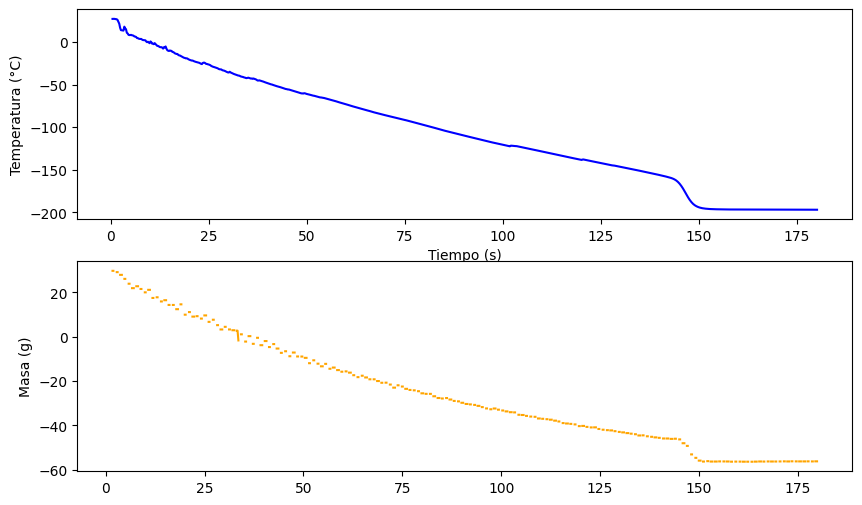

In [73]:
#A1


df = pd.read_csv('mediciones/20260528_113435_balanza_multimetro/20260528_113435_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'], T_ref=1)
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/A1.csv', index=False)

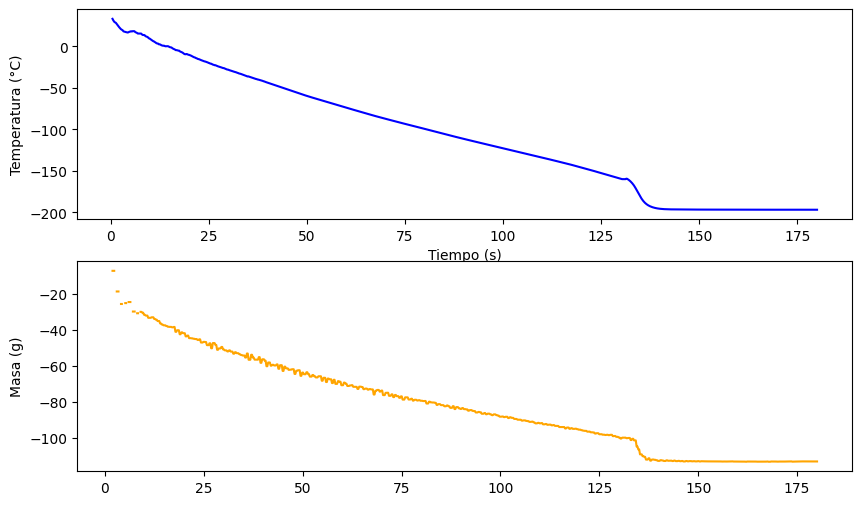

In [ ]:
#A2

df = pd.read_csv('mediciones/20260528_115358_balanza_multimetro/20260528_115358_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'], T_ref=1)
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/A2.csv', index=False)

In [78]:
T

array([ 3.30756349e+01,  3.11227328e+01,  2.95791287e+01,  2.88035301e+01,
        2.82173586e+01,  2.68564323e+01,  2.52923442e+01,  2.39251048e+01,
        2.28604315e+01,  2.18046301e+01,  2.05885357e+01,  1.99839436e+01,
        1.93086565e+01,  1.79846450e+01,  1.76438838e+01,  1.73380087e+01,
        1.70553261e+01,  1.68302682e+01,  1.65712235e+01,  1.69229643e+01,
        1.75243691e+01,  1.76898174e+01,  1.81080282e+01,  1.78249666e+01,
        1.82178469e+01,  1.82282603e+01,  1.81617678e+01,  1.70670704e+01,
        1.65620690e+01,  1.61381484e+01,  1.53460895e+01,  1.53617683e+01,
        1.54778310e+01,  1.54553382e+01,  1.53006000e+01,  1.41790376e+01,
        1.35672728e+01,  1.35882196e+01,  1.34215122e+01,  1.23428087e+01,
        1.17235720e+01,  1.14345457e+01,  1.08191790e+01,  9.65816288e+00,
        9.28310134e+00,  8.53510279e+00,  7.64360863e+00,  6.91617326e+00,
        6.33746189e+00,  5.90261845e+00,  5.16433946e+00,  4.60407339e+00,
        3.73273539e+00,  

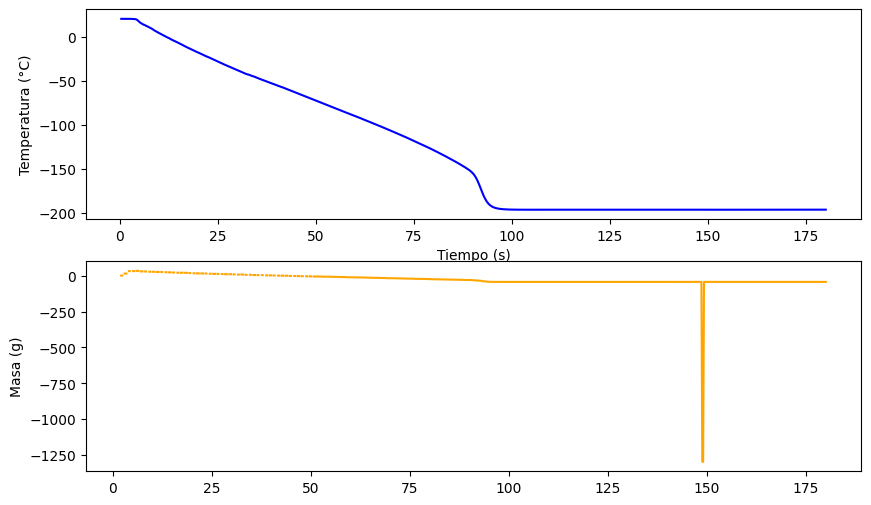

In [88]:
#A3

df = pd.read_csv('mediciones/20260528_121828_balanza_multimetro/20260528_121828_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'], T_ref=1.4)
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/A3.csv', index=False)

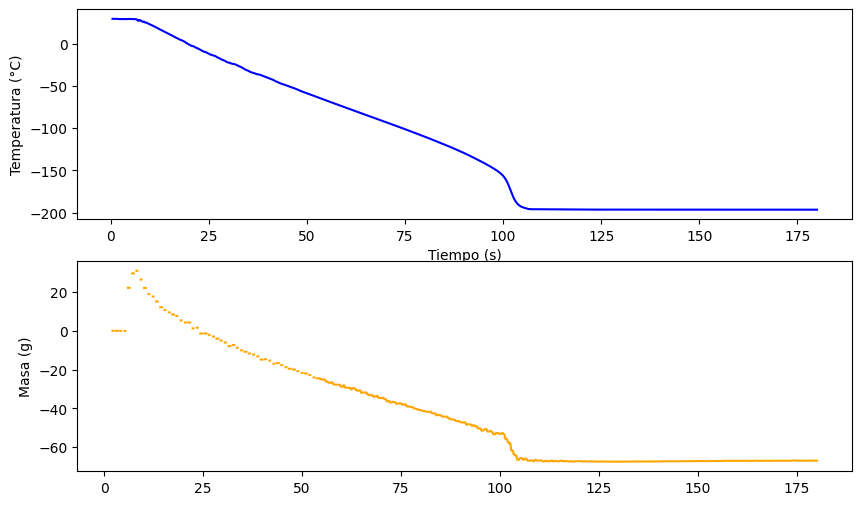

In [96]:
#A3_2

df = pd.read_csv('mediciones/20260528_122723_balanza_multimetro/20260528_122723_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'], T_ref=1.4)
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/A3_2.csv', index=False)

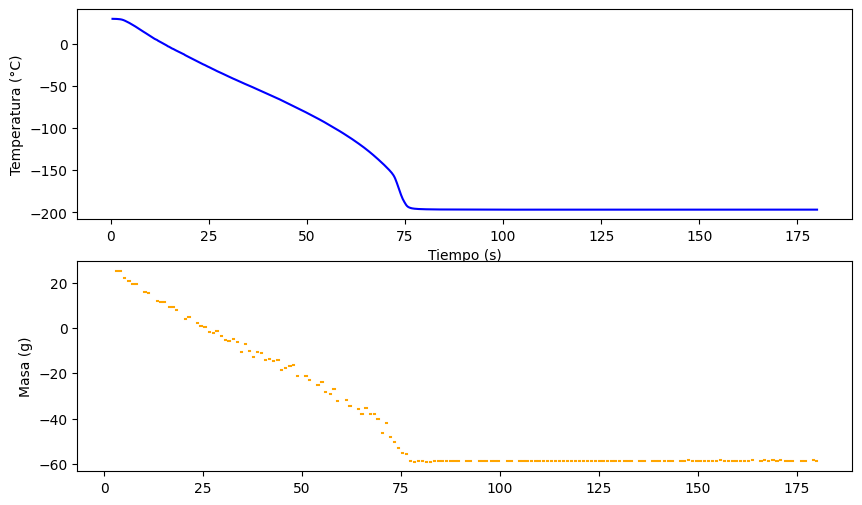

In [ ]:
#A4

df = pd.read_csv('mediciones/20260528_123519_balanza_multimetro/20260528_123519_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'], T_ref=1.4)
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/A4.csv', index=False)

In [94]:
T

array([ 2.98040789e+01,  2.97945374e+01,  2.97679343e+01,  2.97199285e+01,
        2.97000549e+01,  2.96607998e+01,  2.96001389e+01,  2.95273412e+01,
        2.94232653e+01,  2.93003587e+01,  2.91257539e+01,  2.89110970e+01,
        2.86247953e+01,  2.82784693e+01,  2.78764074e+01,  2.74203999e+01,
        2.69274359e+01,  2.64616977e+01,  2.59649260e+01,  2.54370789e+01,
        2.48869297e+01,  2.43188825e+01,  2.37479121e+01,  2.32083496e+01,
        2.25801675e+01,  2.19607485e+01,  2.13880527e+01,  2.07749987e+01,
        2.01413264e+01,  1.94942750e+01,  1.88458308e+01,  1.82161031e+01,
        1.75907454e+01,  1.69757809e+01,  1.63991977e+01,  1.56765309e+01,
        1.50303793e+01,  1.42874247e+01,  1.36011175e+01,  1.30637657e+01,
        1.24101982e+01,  1.17480203e+01,  1.10829680e+01,  1.05277852e+01,
        9.86178823e+00,  9.21785819e+00,  8.55856110e+00,  7.96389314e+00,
        7.19453514e+00,  6.66053454e+00,  5.98095232e+00,  5.52214179e+00,
        4.93907996e+00,  

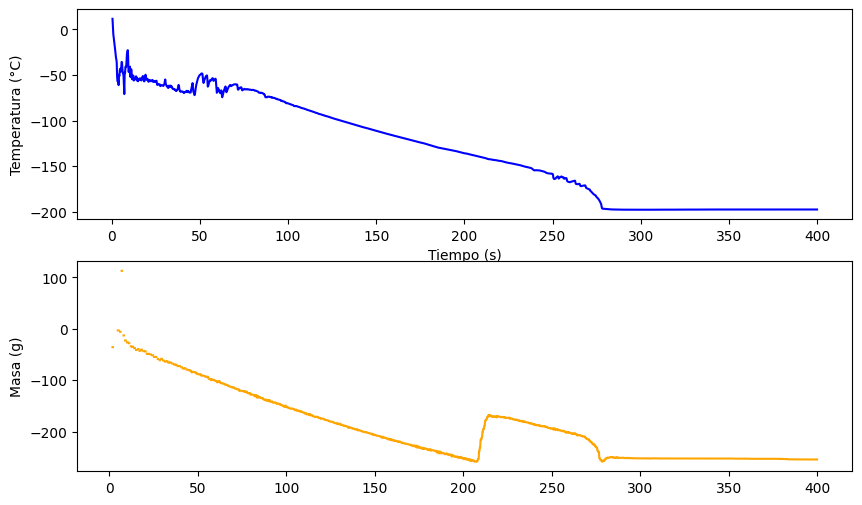

In [98]:
#C1

df = pd.read_csv('mediciones/20260528_130322_balanza_multimetro/20260528_130322_datos_sincronizados_nearest.csv')

fig, ax = plt.subplots(2, 1, figsize=(10,6))
T = convert_type_k_volts_to_c(df['voltaje_V'], T_ref=1.4)
ax[0].plot(df['tiempo_s'], T, label='Temperatura (°C)', color='blue')
ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Temperatura (°C)')
ax[1].plot(df['tiempo_s'], df['masa_g'], label='Masa (g)', color='orange')
ax[1].set_ylabel('Masa (g)')


data = pd.DataFrame({'t': df['tiempo_s'], 'V': df['voltaje_V'], 'T': T, 'W': df['masa_g']}).to_csv('data_clean/C1.csv', index=False)